In [1]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.8/949.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 27.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [2]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO11n model
model = YOLO("yolo11m.pt")


# Run inference with the YOLO11n model on the 'bus.jpg' image
results = model("/content/drive/MyDrive/Colab Notebooks/Machine_vision/4 лаба/b6e9ba8631554ede39ea78968949c338.jpg")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 38.8M/38.8M [00:00<00:00, 196MB/s]



image 1/1 /content/drive/MyDrive/Colab Notebooks/Machine_vision/4 лаба/b6e9ba8631554ede39ea78968949c338.jpg: 480x640 1 cat, 2 dogs, 2061.8ms
Speed: 20.8ms preprocess, 2061.8ms inference, 38.1ms postprocess per image at shape (1, 3, 480, 640)


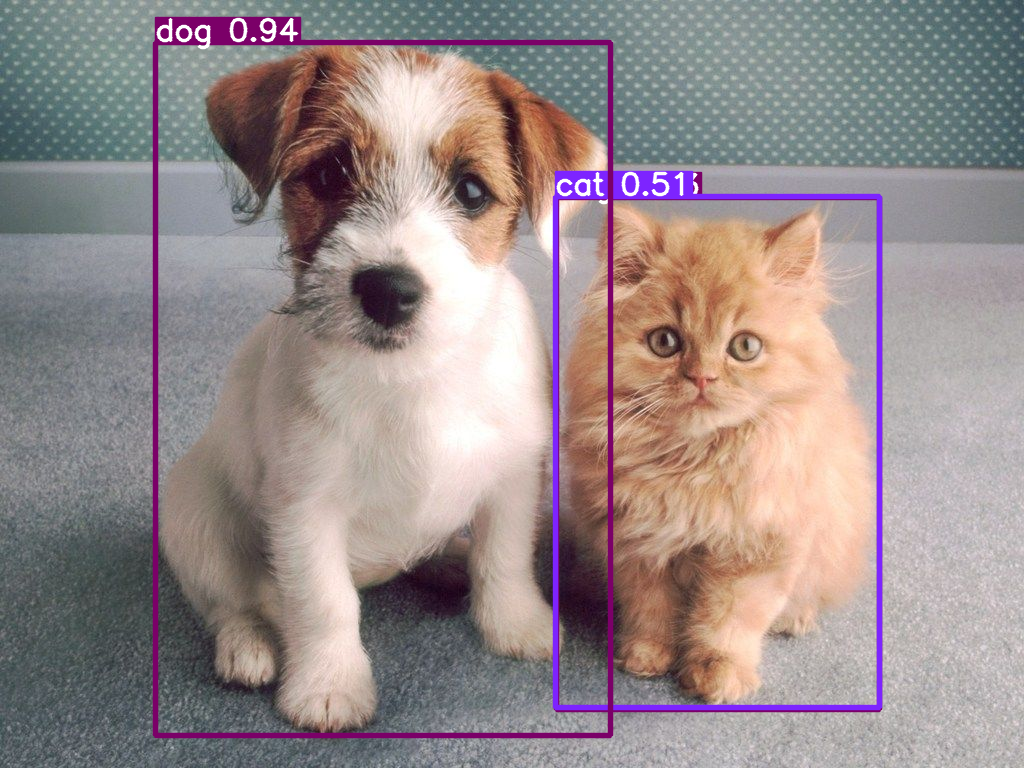

In [3]:
results[0].show()

In [4]:
for result in results:
  for box in result.boxes:
    class_name = result.names[int(box.cls)]
    coordinates = [round(coord, 2) for coord in box.xyxy[0].tolist()]  # [x1, y1, x2, y2] округляем координаты
    confidence = round(box.conf[0].item(), 2) # округляем точность
    print(f"Кто: {class_name}, Где: {coordinates[0],coordinates[1]}{coordinates[2],coordinates[3]}, С вероятностью: {confidence}")

Кто: dog, Где: (155.42, 42.55)(610.32, 735.78), С вероятностью: 0.94
Кто: cat, Где: (555.89, 196.99)(879.26, 707.86), С вероятностью: 0.51
Кто: dog, Где: (556.15, 197.51)(879.46, 709.38), С вероятностью: 0.43



image 1/1 /content/drive/MyDrive/Colab Notebooks/Machine_vision/4 лаба/Мои пчёлы для 4 лабы/0428deefd9de7a8e6ddfbd317f7e246f.jpg: 640x448 1 bird, 1203.7ms
Speed: 6.4ms preprocess, 1203.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 448)


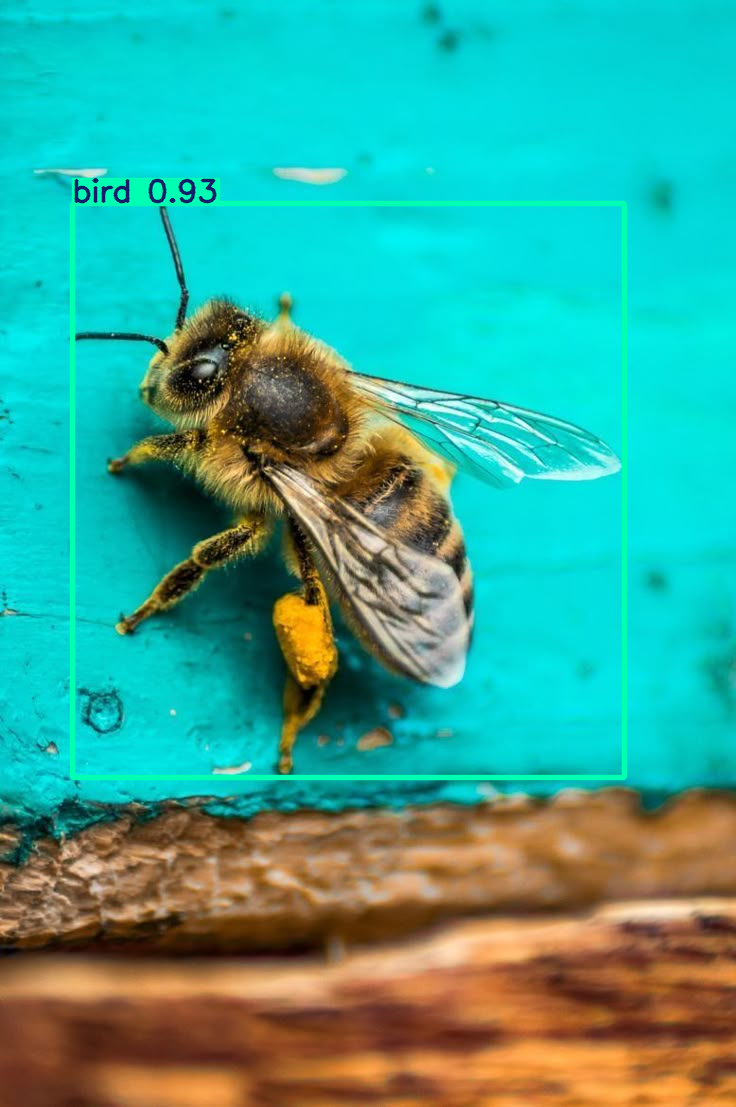

In [5]:
results = model("/content/drive/MyDrive/Colab Notebooks/Machine_vision/4 лаба/Мои пчёлы для 4 лабы/0428deefd9de7a8e6ddfbd317f7e246f.jpg")
results[0].show()

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gvltdY0zkioVW4vmQlfV")
project = rf.workspace("chess-wpyoc").project("hoverfly-cbd4a")
version = project.version(2)
dataset = version.download("yolov11")



loading Roboflow workspace...
loading Roboflow project...


In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml epochs=15 imgsz=128 plots=True

[Errno 2] No such file or directory: '{HOME}'
/content
100% 5.35M/5.35M [00:00<00:00, 63.0MB/s]
Ultralytics 8.3.97 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/Hoverfly-2/data.yaml, epochs=15, time=None, patience=100, batch=16, imgsz=128, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False

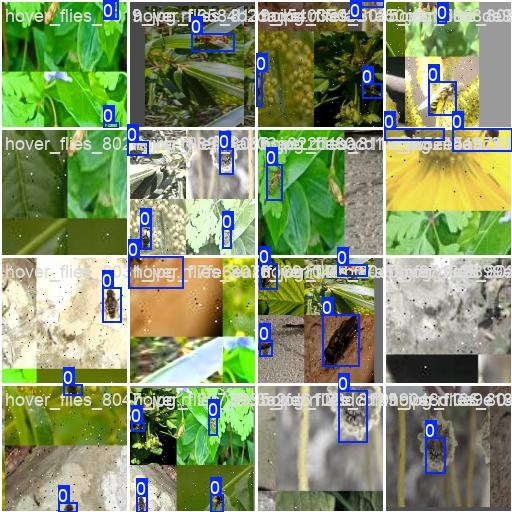

In [3]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/runs/detect/train/train_batch0.jpg', width=600)

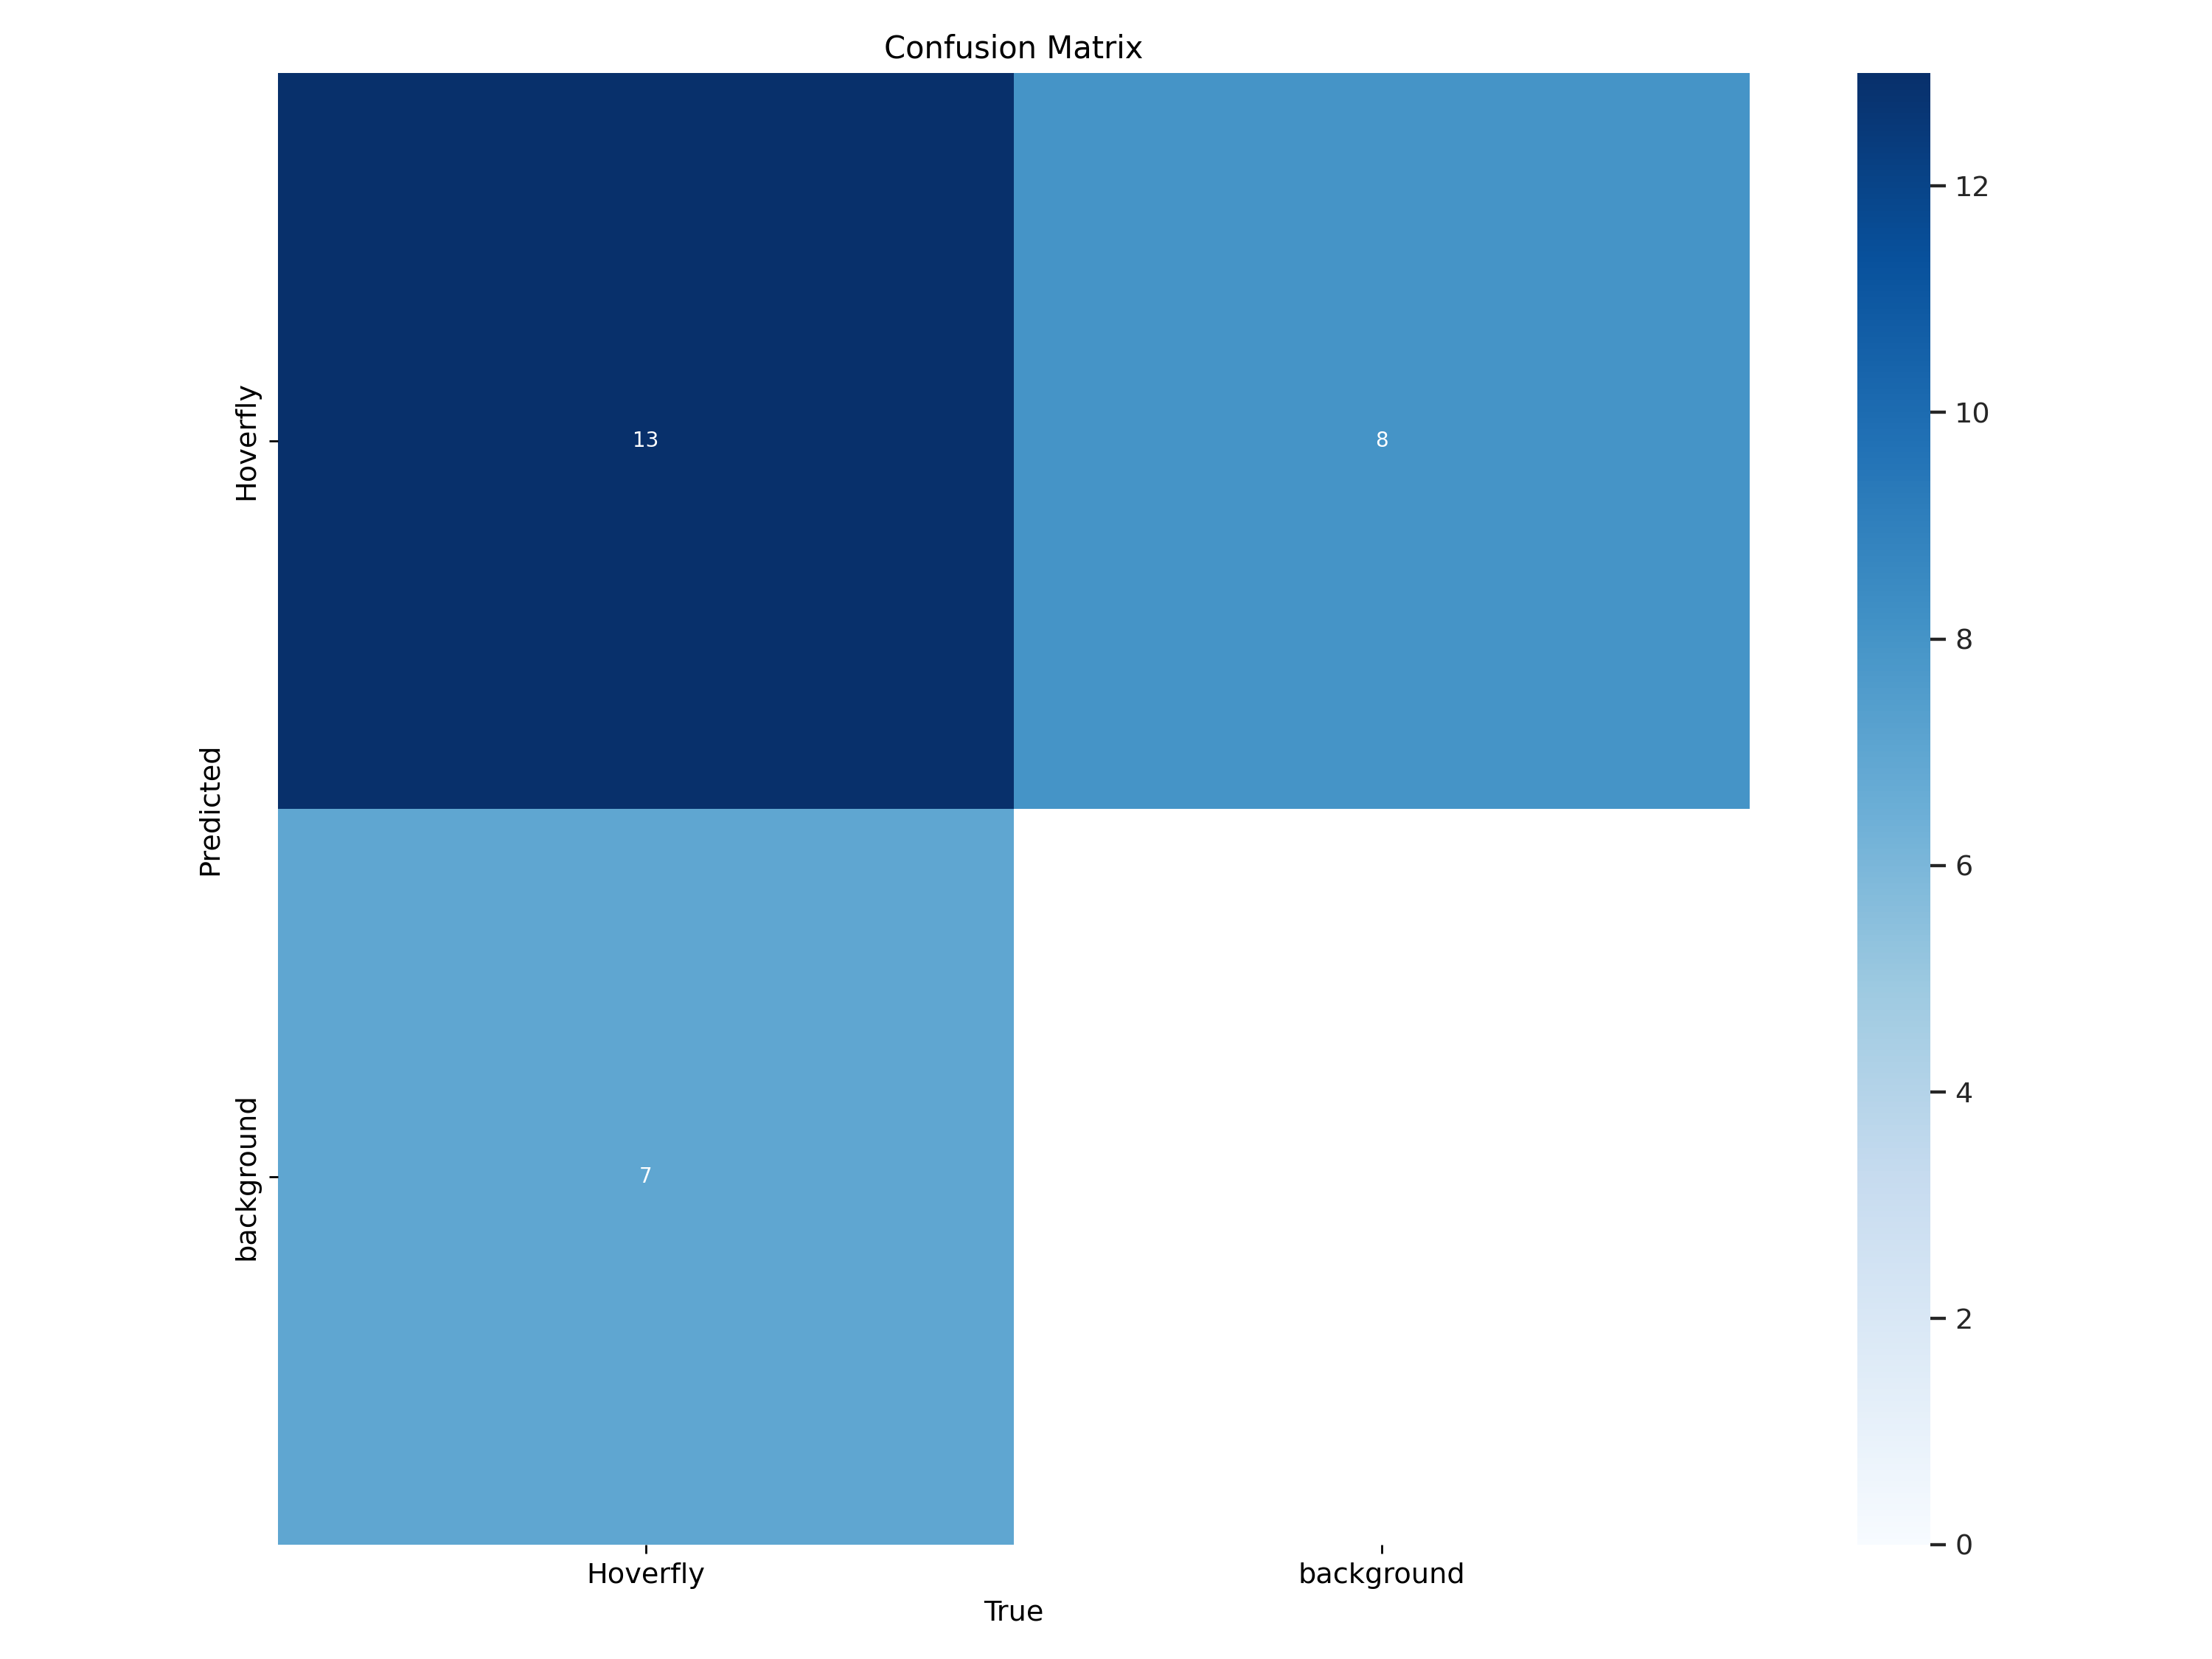

In [4]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/runs/detect/train/confusion_matrix.png', width=600)

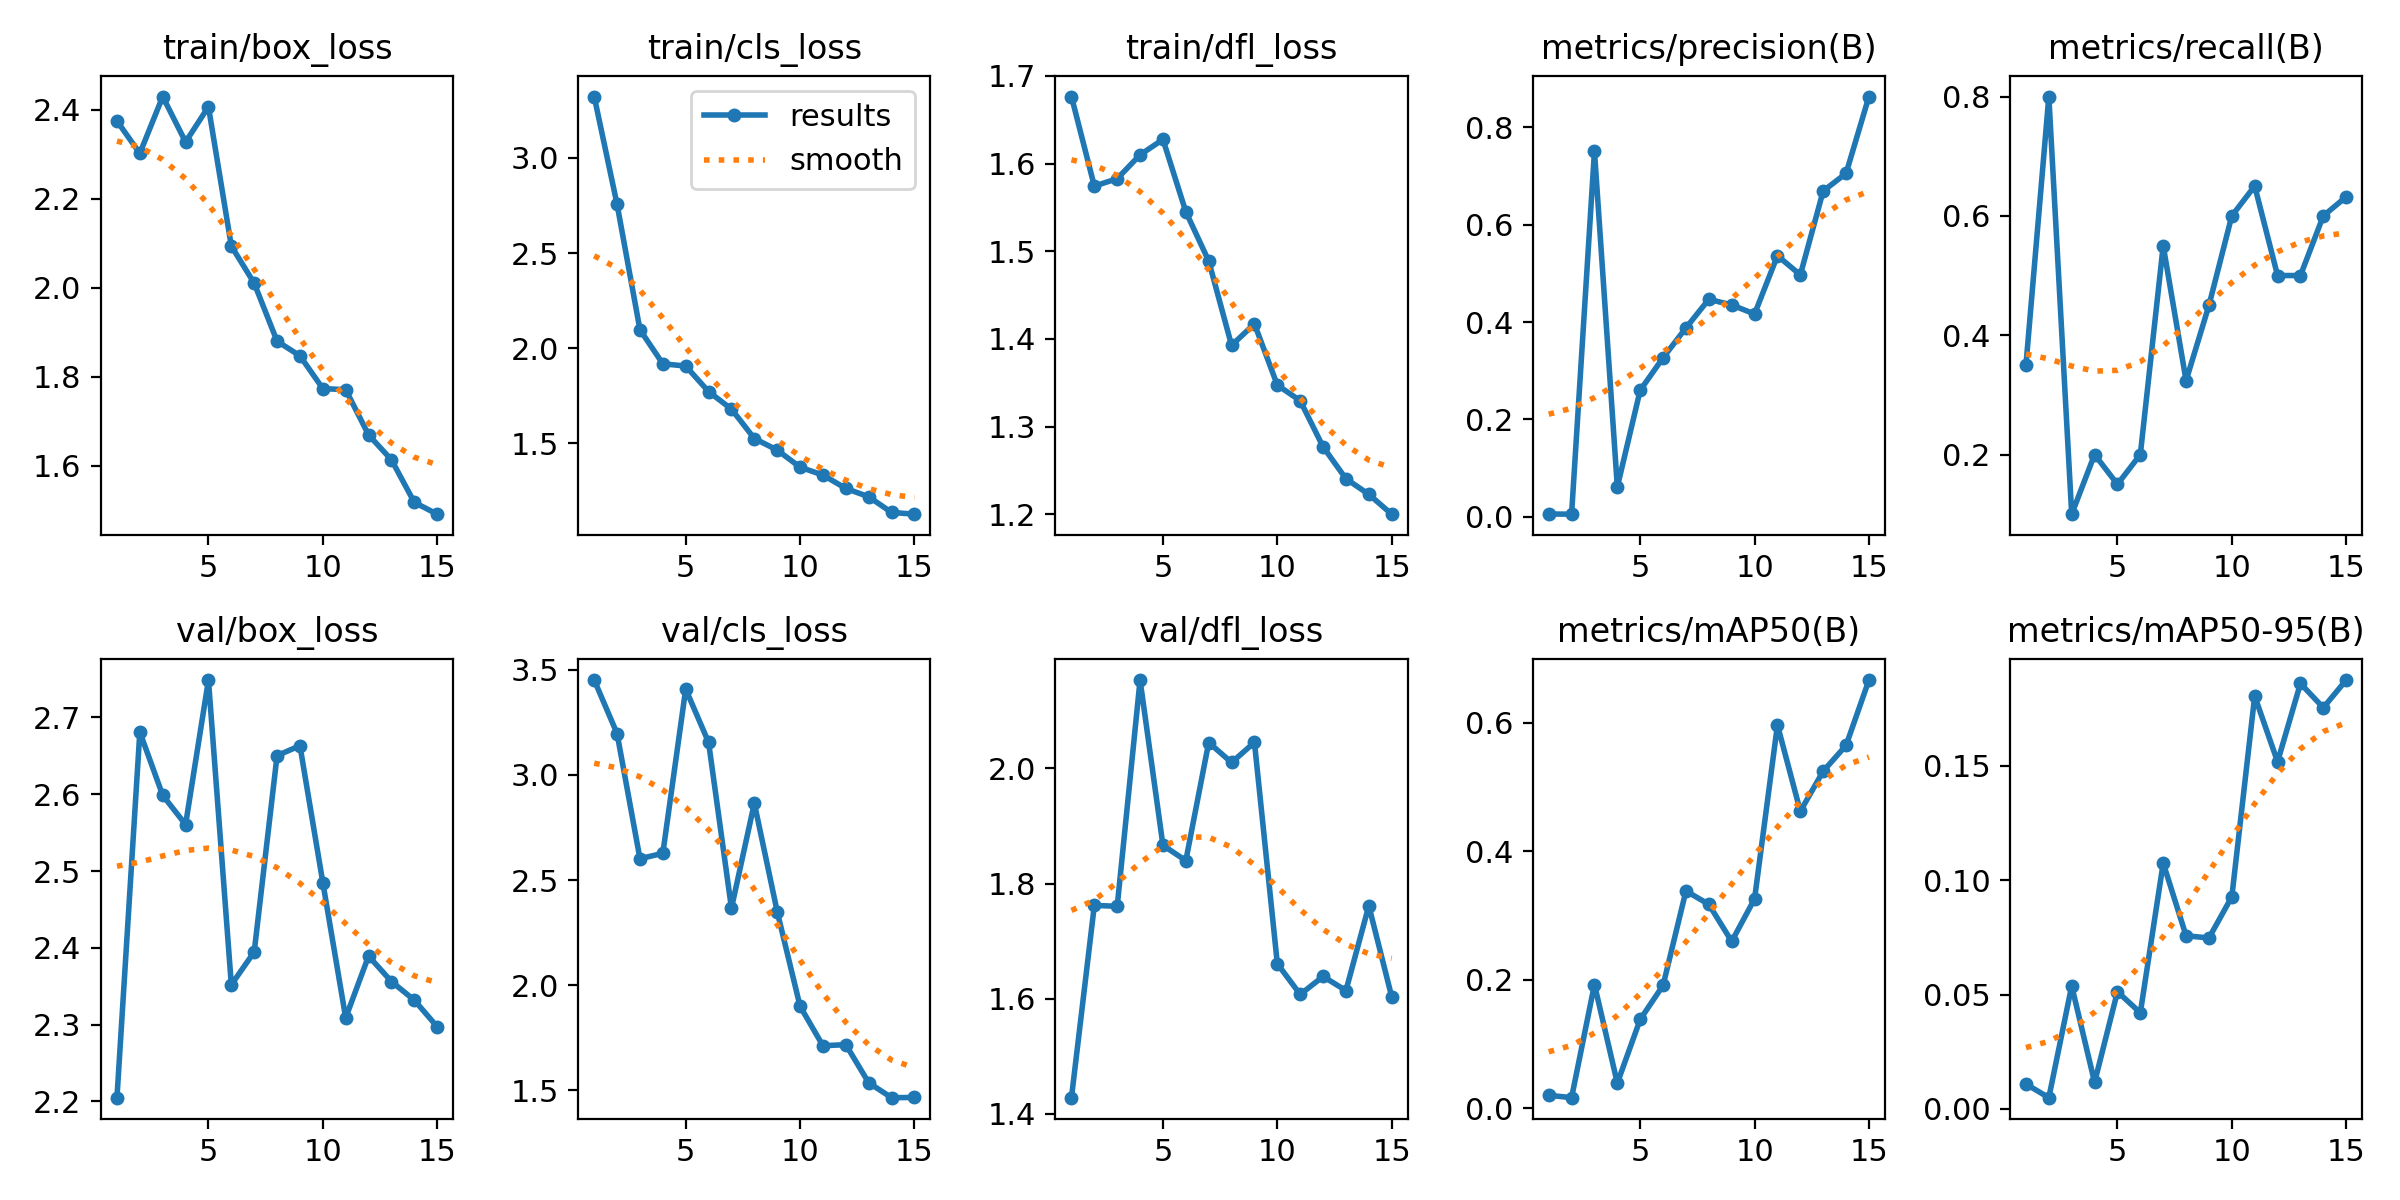

In [5]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/runs/detect/train/results.png', width=600)

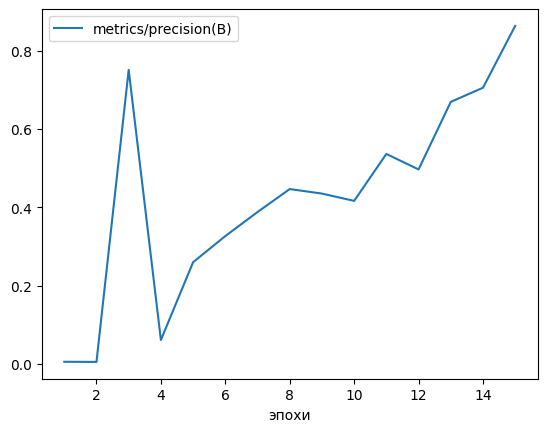

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("/content/runs/detect/train/results.csv")
data

data.plot(x="epoch", y="metrics/precision(B)")
plt.xlabel("эпохи")
plt.show()

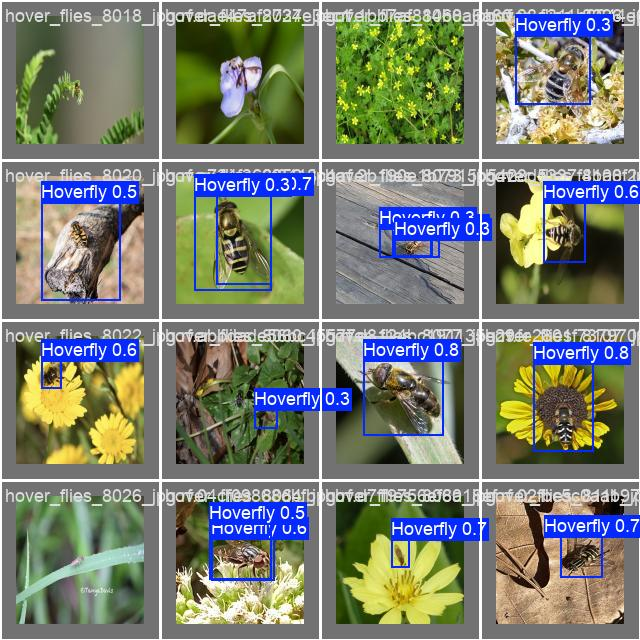

In [9]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/runs/detect/train/val_batch0_pred.jpg', width=600)

In [10]:
from ultralytics import YOLO

# Load a model
model = YOLO("/content/runs/detect/train/weights/best.pt")  # load a custom trained model

# Export the model
model.export(format="onnx")

Ultralytics 8.3.97 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 128, 128) BCHW and output shape(s) (1, 5, 336) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim', 'onnxruntime'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 138.9 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 12.4s, installed 3 packages: ['onnx>=1.12.0', 'onnxslim', 'onnxruntime']
requirements: ⚠️ Restart runtime or rerun command for update

'/content/runs/detect/train/weights/best.onnx'


image 1/1 /content/drive/MyDrive/Colab Notebooks/Machine_vision/4 лаба/Мои пчёлы для 4 лабы/0428deefd9de7a8e6ddfbd317f7e246f.jpg: 128x96 1 Hoverfly, 21.5ms
Speed: 0.9ms preprocess, 21.5ms inference, 1.0ms postprocess per image at shape (1, 3, 128, 96)


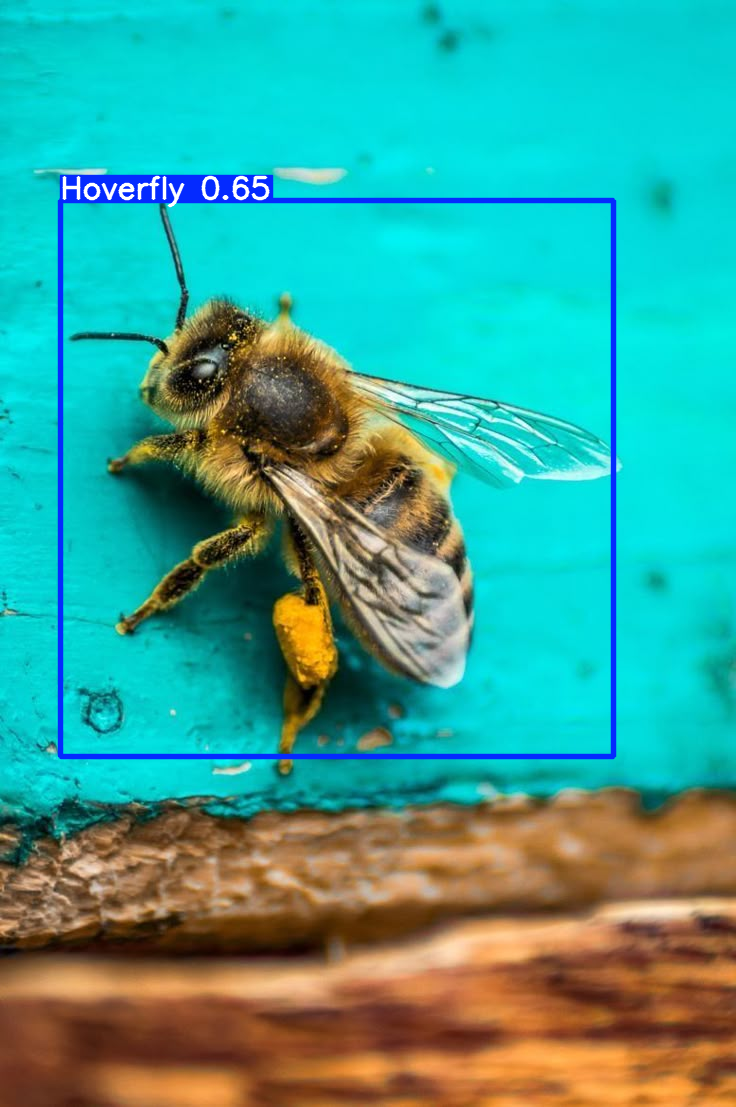

In [18]:
results = model("/content/drive/MyDrive/Colab Notebooks/Machine_vision/4 лаба/Мои пчёлы для 4 лабы/0428deefd9de7a8e6ddfbd317f7e246f.jpg")
results[0].show()

In [19]:
for result in results:
  for box in result.boxes:
    class_name = result.names[int(box.cls)]
    coordinates = [round(coord, 2) for coord in box.xyxy[0].tolist()]  # [x1, y1, x2, y2] округляем координаты
    confidence = round(box.conf[0].item(), 2) # округляем точность
    print(f"Кто: {class_name}, Где: {coordinates[0],coordinates[1]}{coordinates[2],coordinates[3]}, С вероятностью: {confidence}")

Кто: Hoverfly, Где: (60.67, 200.26)(613.82, 756.67), С вероятностью: 0.65
